#Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

#Get the Data

In [2]:
df = pd.read_csv('CC_GENERAL.csv')

In [3]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.shape

(8950, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [6]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


#Data Cleaning

#####Delete CUST_ID Column

In [7]:
df = df.drop('CUST_ID', axis=1)

##### Checking Missing Values

In [8]:
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


In [9]:
df.fillna(df.mean(), inplace=True)

In [10]:
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


#Exploratory Data Analysis

####Histogram

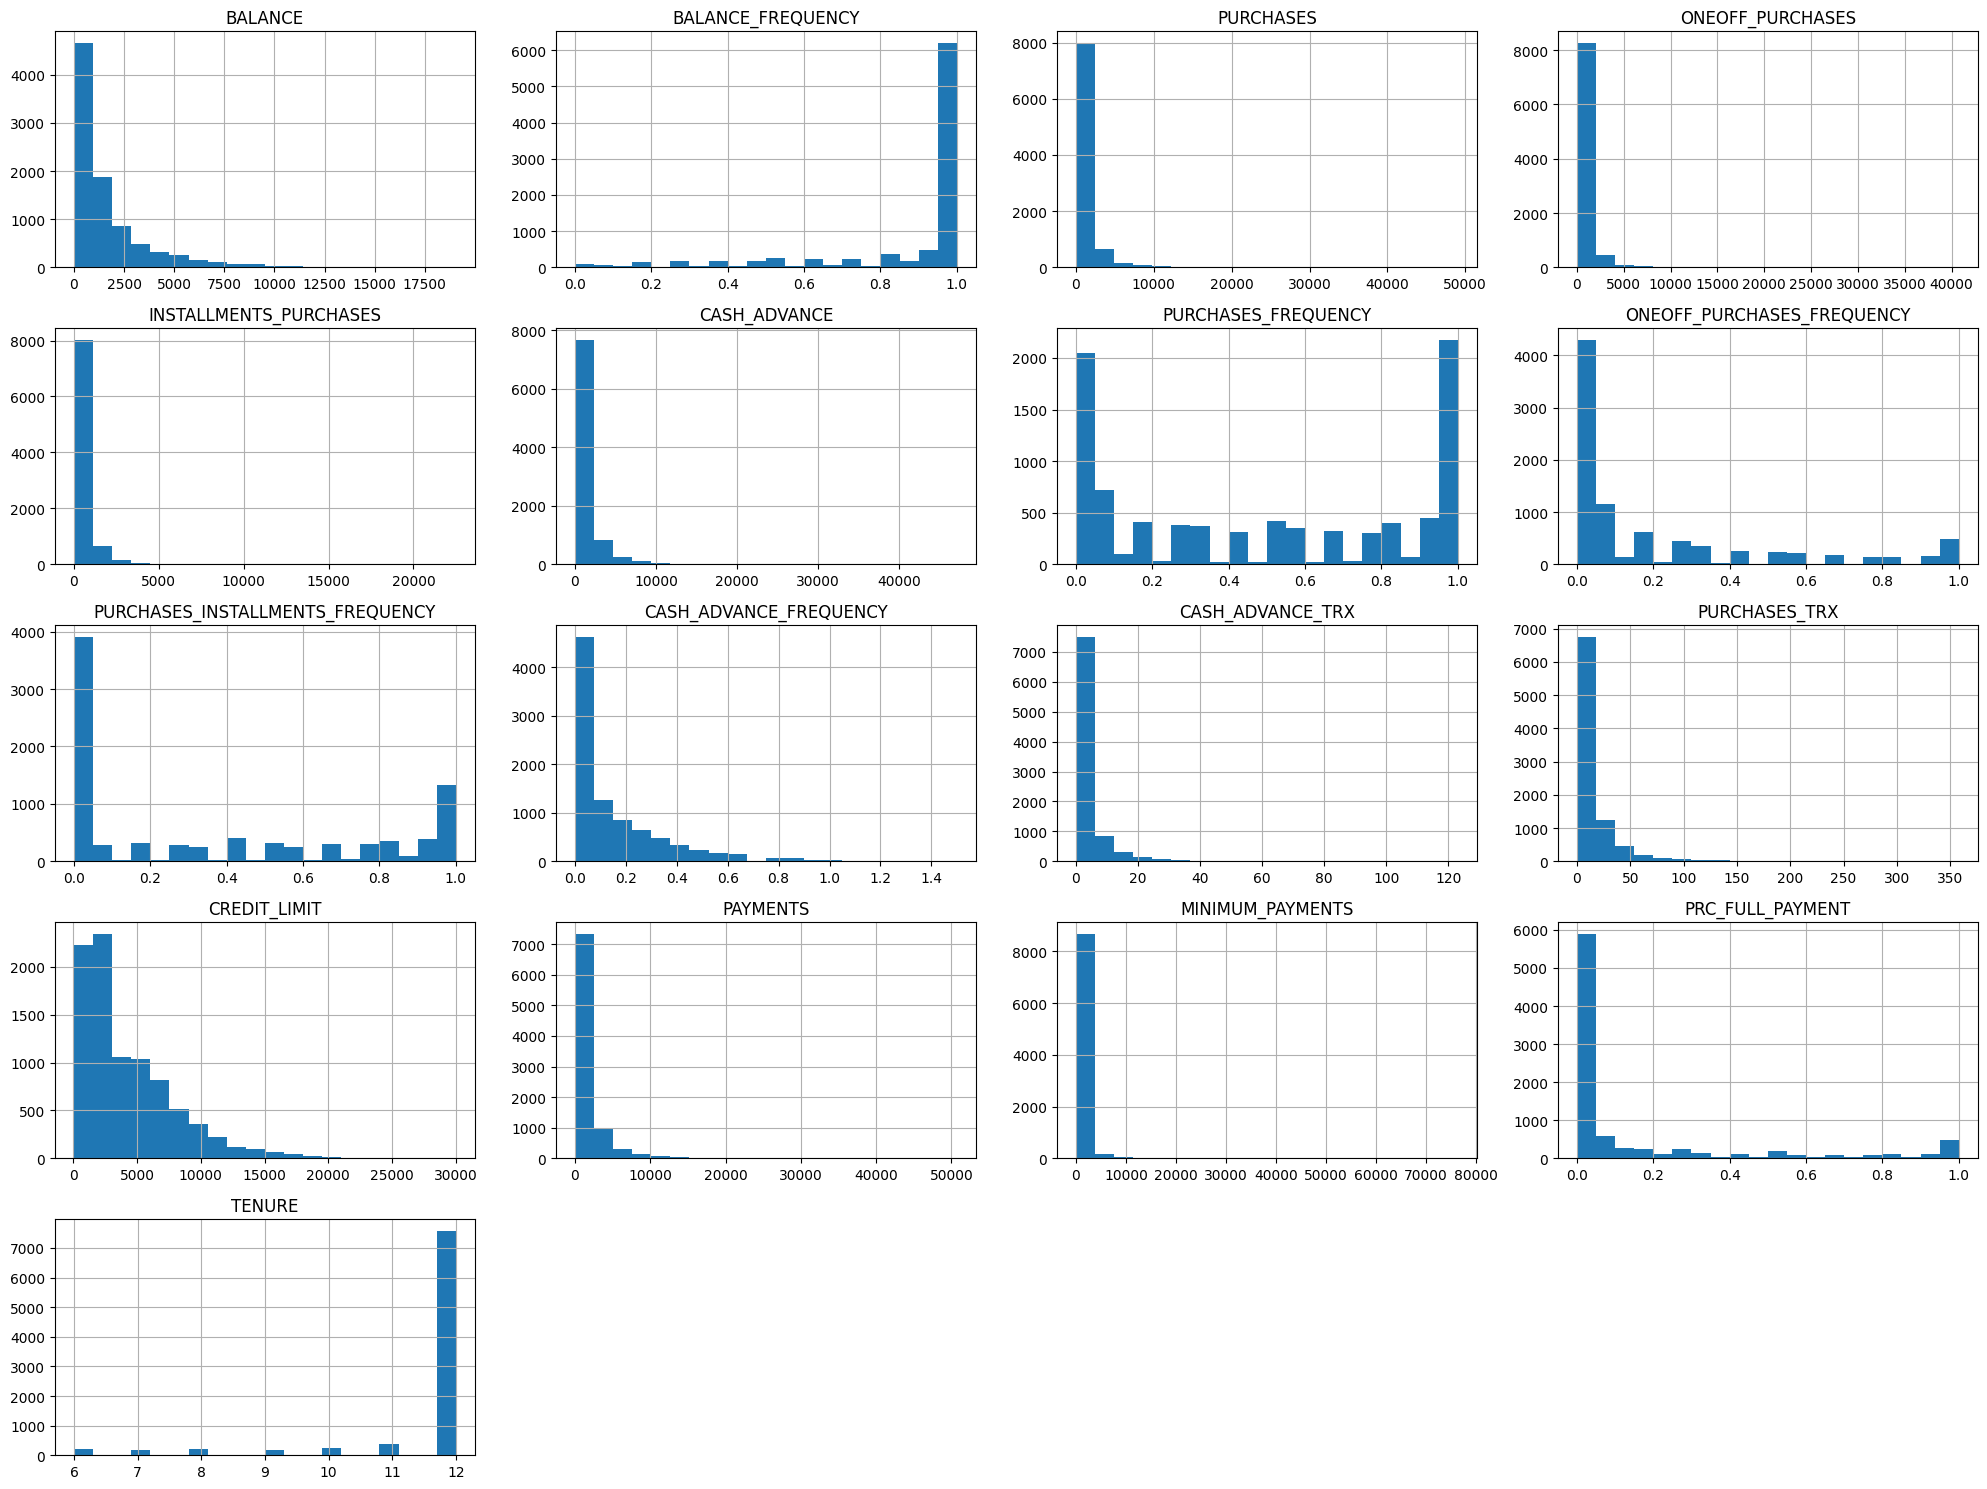

In [11]:
df.hist(figsize=(20,15), bins=20)
plt.tight_layout()
plt.show()

####Correlation Heatmap

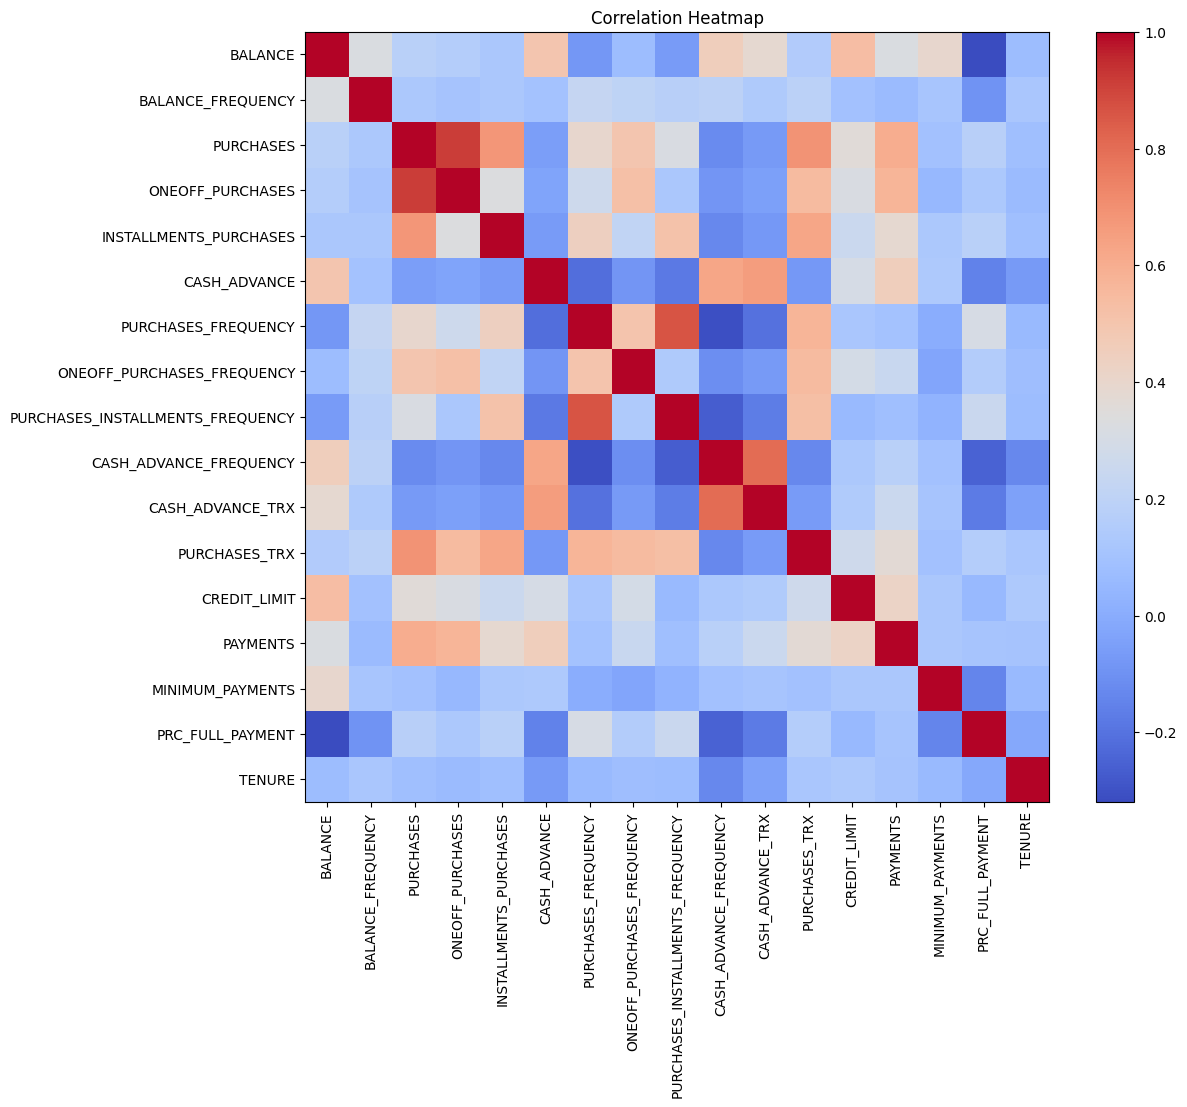

In [12]:
plt.figure(figsize=(12,10))

plt.imshow(df.corr(), cmap='coolwarm', aspect='auto')

plt.colorbar()

plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)

plt.title('Correlation Heatmap')

plt.show()

####Scatter Between BALANCE and PURCHASES

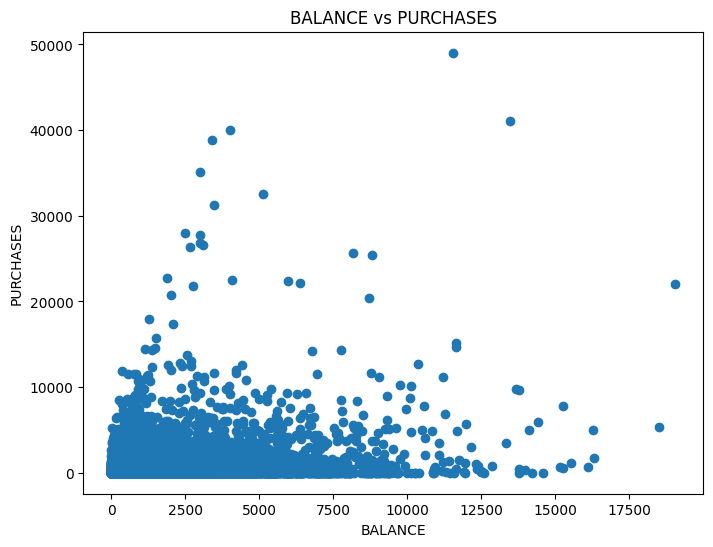

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(df['BALANCE'], df['PURCHASES'])

plt.xlabel('BALANCE')
plt.ylabel('PURCHASES')

plt.title('BALANCE vs PURCHASES')

plt.show()

####Scatter Between BALANCE and CASH_ADVANCE

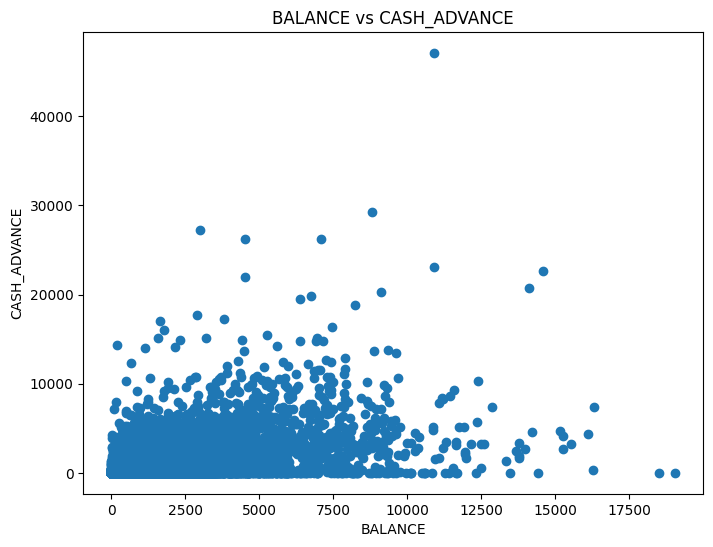

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(df['BALANCE'], df['CASH_ADVANCE'])

plt.xlabel('BALANCE')
plt.ylabel('CASH_ADVANCE')

plt.title('BALANCE vs CASH_ADVANCE')

plt.show()

#Feature Scaling

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

#Elbow Method

In [16]:
inertia_values = []

K_range = range(1,11)

for k in K_range:

    model = KMeans(n_clusters=k, random_state=42, n_init=10)

    model.fit(X_scaled)

    inertia_values.append(model.inertia_)

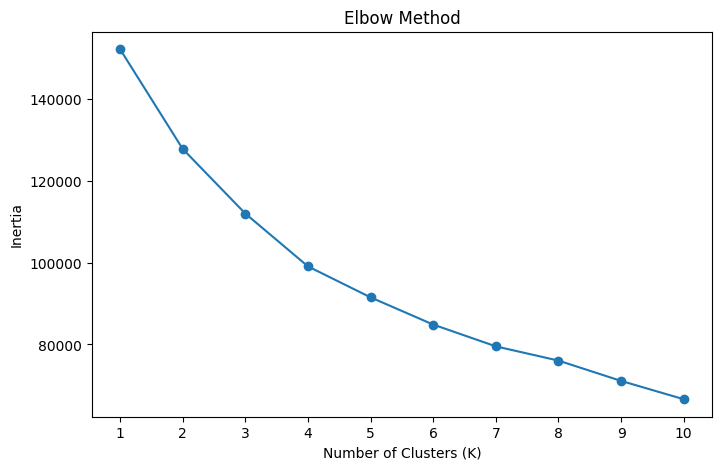

In [17]:
plt.figure(figsize=(8,5))

plt.plot(K_range, inertia_values, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.title('Elbow Method')

plt.xticks(K_range)

plt.show()

#Silhouette Score

In [18]:
silhouette_scores = []

K_range = range(2,11)

for k in K_range:

    model = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

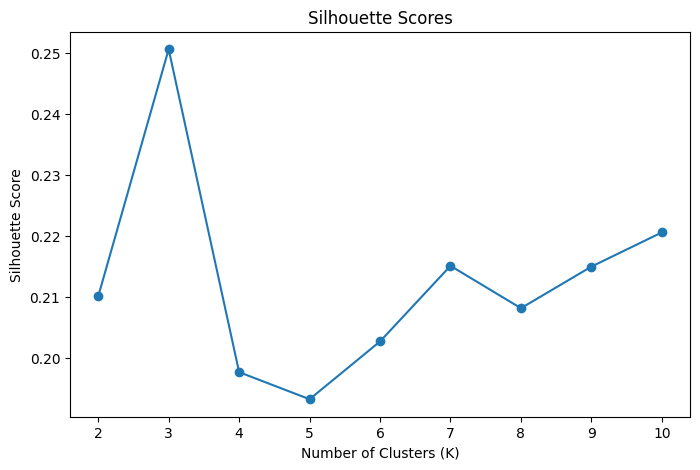

In [19]:
plt.figure(figsize=(8,5))

plt.plot(K_range, silhouette_scores, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')

plt.title('Silhouette Scores')

plt.xticks(K_range)

plt.show()

In [20]:
score_table = pd.DataFrame({

    'K': list(range(2,11)),

    'Silhouette Score': silhouette_scores
})

score_table

,K,Silhouette Score
0,2,0.210033
1,3,0.250556
2,4,0.197607
3,5,0.193169
4,6,0.202639
5,7,0.215038
6,8,0.208092
7,9,0.214912
8,10,0.220518


#Final K-Means Model

In [21]:
final_model = KMeans(n_clusters=4, random_state=42, n_init=10)

df['Cluster'] = final_model.fit_predict(X_scaled)

In [22]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,3
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,3


#Cluster Analysis

In [23]:
cluster_summary = df.groupby('Cluster').mean()

cluster_summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,894.907458,0.934734,1236.178934,593.974874,642.478274,210.570626,0.885165,0.297070,0.711842,0.042573,0.790021,22.091773,4213.207678,1332.194205,650.167072,0.269258,11.594595
1,3551.153761,0.986879,7681.620098,5095.878826,2587.208264,653.638891,0.946418,0.739031,0.788060,0.071290,2.085575,89.359413,9696.943765,7288.739497,1976.815179,0.286707,11.951100
2,4602.462714,0.968415,501.896219,320.373681,181.607404,4520.724309,0.287731,0.138934,0.185516,0.484526,14.284641,7.661102,7546.957050,3481.145990,2008.251157,0.034859,11.387312
3,1011.751528,0.789871,269.973466,209.853863,60.386625,595.759339,0.170146,0.086281,0.080578,0.114833,2.125503,2.903421,3277.703165,974.505090,586.301239,0.078001,11.446429


In [24]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,3367
1,409
2,1198
3,3976


#PCA Visualization

In [25]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

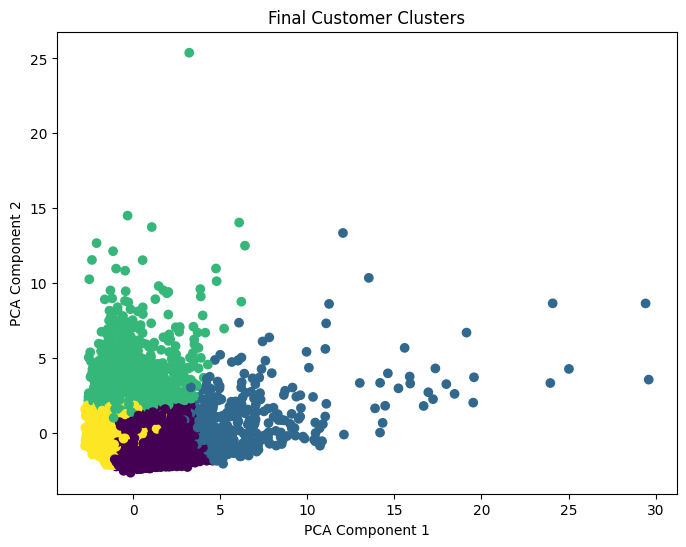

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['Cluster'],
    cmap='viridis'
)

plt.title('Final Customer Clusters')

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.show()

#Answer for Final Questions:

1. Why is this an unsupervised learning problem?

- Because the dataset does not contain target labels or predefined customer groups.
----

2. Why did we remove the `CUST_ID` column?
- Because it is only an identification column and does not describe customer behavior.
----

3. Which columns had missing values?
- Some numerical columns such as MINIMUM_PAYMENTS and CREDIT_LIMIT had missing values.

----
4. How did you handle the missing values?
- We filled the missing values using the mean of each column.
----

5. Why is scaling important before applying K-Means?
- Because K-Means depends on distance calculations, and large-scale features can dominate smaller-scale features.

6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.
- We selected K = 4  based on the elbow method and silhouette score because it provided clear cluster separation.
----

7. Based on the cluster summary table, describe each customer segment in your own words.
- One cluster contains high-spending customers.
- Another cluster contains customers with high cash advance usage.
- Some clusters represent moderate or low activity customers.
----
8. Which cluster may represent high-value customers?
-The cluster with high purchases, high balance, and high credit limit may represent high-value customers.
----

9. Which cluster may represent customers who rely more on cash advance?
- The cluster with high CASH_ADVANCE values likely represents customers who rely more on cash advances.
-----

10. How can a company use these clusters for marketing strategy?
- Companies can use clusters for targeted marketing, personalized offers, customer retention, and risk analysis.